# Three Decades of Spanish Football: A Comprehensive La Liga Analytical Dataset (1995–2025)
This project features a large dataset covering 30 years of La Liga match results, from the 1995-96 season through the first ten matchdays of 2025-26. By unifying fragmented seasonal data into a single, streamlined resource, this project enables deep-dive Exploratory Data Analysis (EDA) into the evolution of Spanish football.

The analysis explores three critical dimensions of the sport:

* **Historical Trends**: Analyzing home-field advantage (including the "Ghost Games" of 2020) and goal-scoring evolution.
* **The Power Dynamics**: Comparing the dominance of "The Big Two" (Real Madrid and Barcelona) against the rest of the league.
* **Predictive Metrics**: Evaluating the correlation between half-time leads and final outcomes, as well as tracking the statistical decline of former giants like Deportivo La Coruña and Valencia.


### Data Familiarization & The Home Field Advantage
Before diving into our complex analysis, we need to establish the baseline of our dataset. The first step to is to check the shape of the dataset, look for missing values (Null/NaN), verify data types, and ensure the Season column is formatted consistently so you can easily group by it later.

#### Initial Setup & Inspection

In [1]:
import pandas as pd
import numpy as np

# Importing the dataset
df = pd.read_csv('LaLiga_Matches.csv')


# Sanity Check + checking for null/NaN values 
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11664 entries, 0 to 11663
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Season    11664 non-null  object 
 1   Date      11664 non-null  object 
 2   HomeTeam  11664 non-null  object 
 3   AwayTeam  11664 non-null  object 
 4   FTHG      11664 non-null  int64  
 5   FTAG      11664 non-null  int64  
 6   FTR       11664 non-null  object 
 7   HTHG      11662 non-null  float64
 8   HTAG      11662 non-null  float64
 9   HTR       11662 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 911.4+ KB


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,2.0,0.0,H
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3.0,0.0,H
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,2.0,0.0,H
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0.0,0.0,D


#### Historical Baseline Calculation
After checking that there are no missing values (Null/NaN), verifying data types, and ensuring the Season column is formatted correctly, we can move onto calculating the Historical Baseline. We will use the FTR (Full-time result) column, calculate the historical win rate for Home teams (H), Away teams (A), and the rate of Draws (D) across the entire dataset (1995 to 2025).

In [2]:
# Getting baseline w/l/d % for all 3 decades 
stats_pct = df['FTR'].value_counts(normalize = True).reset_index().rename(columns = {'proportion': 'WinRatePct'})
stats_pct['Era'] = 'Historical'

# Isolating the 2020-21 season + getting the w/l/d % for this specific season
df_season_2020_21 = df[df['Season'] == '2020-21']
stats_pct_2020_21 = df_season_2020_21['FTR'].value_counts(normalize = True).reset_index().rename(columns = {'proportion': 'WinRatePct'})
stats_pct_2020_21['Era'] = '2020-21'

# Sanity check 
print(stats_pct)
print(stats_pct_2020_21)


  FTR  WinRatePct         Era
0   H    0.471536  Historical
1   A    0.271948  Historical
2   D    0.256516  Historical
  FTR  WinRatePct      Era
0   H    0.415789  2020-21
1   A    0.297368  2020-21
2   D    0.286842  2020-21


In [3]:
# Merging dataframes to use in the visaulization
merged_stats_pcts = pd.concat([stats_pct, stats_pct_2020_21])
print(merged_stats_pcts)

  FTR  WinRatePct         Era
0   H    0.471536  Historical
1   A    0.271948  Historical
2   D    0.256516  Historical
0   H    0.415789     2020-21
1   A    0.297368     2020-21
2   D    0.286842     2020-21


#### The Empty Stadium Anomaly and Visualization

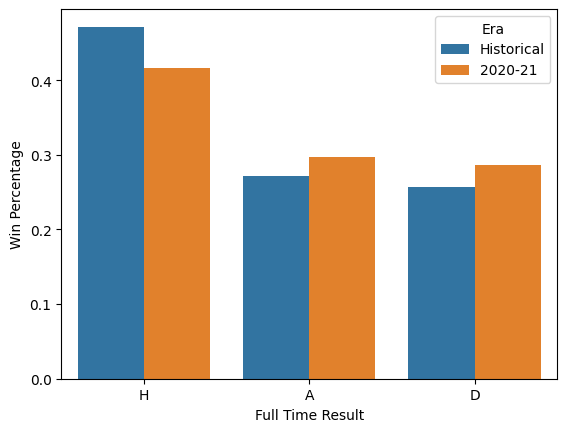

In [4]:
import matplotlib.pyplot as plt
import seaborn as sb

sb.barplot(x = 'FTR', 
           y = 'WinRatePct', 
           hue = 'Era',
           data = merged_stats_pcts)


plt.xlabel('Full Time Result')
plt.ylabel('Win Percentage')
plt.show()



The data reveals a significant decrease in **Home Field Advantage** during the 2020-21 'Ghost Season'. We saw **Home win rates drop by approximately 5.6 percent points** compared to the 30-year baseline (from **47.2%** to **41.6%**). This declined was transfered by a nearly equal rise in both away wins and draws, suggesting that the absence of a home crown helped level the playing field.

### Goal Scoring Trends
For this part of the EDA I want to take a look at a couple of questions: 

* What is the average number of goals scored per match for each season?
* Is the league becoming more or less offensive over time?

We will start to solve this problem by creating a column called `TotalGoals` that represents the total number of goals scored in each specific match.

In [5]:
# Finding TotalGoals by adding both columns together
df['TotalGoals'] = df['FTAG'] + df['FTHG']

# Sanity Check
df.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,TotalGoals
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,2.0,0.0,H,3
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3.0,0.0,H,3
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,2.0,0.0,H,4
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D,5
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0.0,0.0,D,1


#### Aggregating goals by Season
Now that we have the total goals per match, we need to group our data by the Season column. Then we need to calculate the average (mean) of your new TotalGoals column for each season.

In [6]:
df.groupby('Season')['TotalGoals'].mean()

Season
1995-96      2.696970
1996-97      2.751082
1997-98      2.655263
1998-99      2.639474
1999-2000    2.628947
2000-01      2.881579
2001-02      2.528947
2002-03      2.673684
2003-04      2.671053
2004-05      2.578947
2005-06      2.463158
2006-07      2.478947
2007-08      2.686842
2008-09      2.897368
2009-10      2.713158
2010-11      2.742105
2011-12      2.763158
2012-13      2.871053
2013-14      2.750000
2014-15      2.655263
2015-16      2.744737
2016-17      2.942105
2017-18      2.694737
2018-19      2.586842
2019-20      2.478947
2020-21      2.507895
2021-22      2.502632
2022-23      2.513158
2023-24      2.644737
2024-25      2.618421
2025-26      2.610000
Name: TotalGoals, dtype: float64

#### Trend Analysis and Visualization
Now that we have our result, we determine based on the data, is La Liga becoming more offensive, less offensive, or staying roughly the same over time by looking at the visualization. 

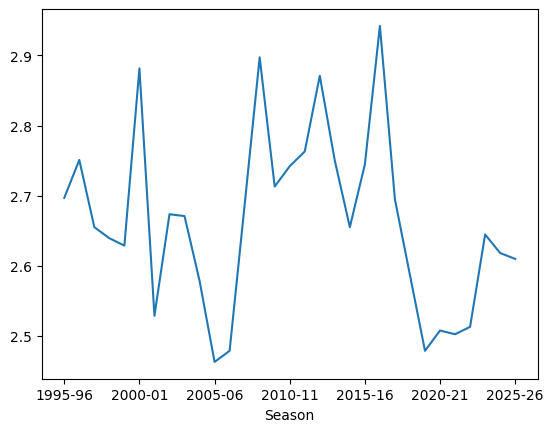

In [7]:
df.groupby('Season')['TotalGoals'].mean().plot()
plt.show()

If we look closely at between the years 2008 and 2017, it perfectly aligns with the peak years of Lionel Messi at Barcelona and Cristiano Ronaldo at Real Madrid, where both teams were frequently scoring 100+ goals a season. The recent dip makes sense given that that have both left their respective clubs. 

### Halftime Predictive Power
We now want to focus on tackling the following question: 

* How often does the team leading at halftime go on to win the match? Conversely, what is the 'comeback rate' for teams trailing at halftime?

To solve this, we need to compare the HTR (Half-time result) column with the FTR (Full-time result) column.

#### Isolate Halftime Leaders
We need to filter our data frame to only look at mathches where tehre was clear leader at halftime (meaning HTR is either 'H' for Home or 'A' for Away). We want to exclude games that were drawn ('D') at halftime for this specific calculation.

In [8]:
# Filtering out all the games where the teams were drawing againts each other at halftime
filtered_df = df[df['HTR'] != 'D']

# Sanity Check
filtered_df['HTR'].value_counts()

HTR
H    4104
A    2587
Name: count, dtype: int64

#### Calculating the "Hold the Lead" Rate
To calculate the "Hold the Lead" rate we are essentially asking ourselves: 

* Out of all the games where a team was leading at halftime, what percentage of them ended with that same team winning at full-time?

We start off by counting the number of games where the Half Time Result (HTR) is the same as the Full Time Result (FTR).

In [9]:
# This sums all the games in which the team who was leading at half time ended up winning 
hold_lead_count = (filtered_df['HTR'] == filtered_df['FTR']).sum()

# Getting the rate at which leading at half time leads to the team winning
hold_lead_rate = round((hold_lead_count / len(filtered_df)) * 100, 2)

print('Hold the Lead Rate: ')
print(str(hold_lead_rate) + '%')

Hold the Lead Rate: 
75.29%


We got that if a team goes into the locker room at halftime with the lead, they have a roughly 3-in-4 (**75.29%**) chance of securing all three points. 

#### Calculating the "Comeback" Rate
Similarly to how we calculated the "Hold the Lead" rate, we want to calculate how often to combacks happen. In order to answer this we are answering: 

* Out of all the games where a team was leading at halftime, what percentage of them ended with the trailing team pulling off a comeback win? (e.g., Home team leads at half, but Away team wins at full-time).

We start off by counting the number of games where the Half Time Result (HTR) is not the same Full Time Result (FTR) and the FTR is not a Draw.

In [10]:
# This sums all the games in which there was a comback and didn't end in a draw.
comeback_count = ((filtered_df['HTR'] != filtered_df['FTR']) & (filtered_df['FTR'] != 'D')).sum()

# Getting the rate at which this happens
comback_rate = round((comeback_count / len(filtered_df)) * 100, 2)

print('Comeback Rate: ')
print(str(comback_rate) + '%')

Comeback Rate: 
7.87%


This really puts into perspective how difficult it is to change the trajectory of a game in a professional football match. This low percentage suggest that once a team is in the lead they establish more defensive structure and are better at managing the clock and neutralizing threats.

### Comparative Analysis (The Big Two vs. The Rest)
Now instead of looking at the league as a whole, we are going to start slicing the data to compare specific groups. More specifically we are going to be focusing on the two biggest teams in La Liga (Real Madrid and Barcelona). The very first question we will answer is the following: 

* Compare the average goal difference per match for Real Madrid and Barcelona against the rest of the league. How has this gap evolved from the late 90s to today?

The first step in answering this question is to create Goal Difference Columns; `Home_GD` (Home Goals minus Away Goals), and `Away_GD` (Away Goals minus Home Goals). 


In [11]:
# Creating home goal difference column (FTHG - FTAG)
df['Home_GD'] = df['FTHG'] - df['FTAG']

# Creating away goal difference column (FTHG - FTAG)
df['Away_GD'] = df['FTAG'] - df['FTHG']


#### Isolating the Big Two
Now that we have the Goal Difference per match, we need to filter our dataframe so that it only contains matches for for Real Madrid and Barcelona. So that we can calculate the average Goal Difference. 

In [12]:
home_madrid = df[df['HomeTeam'] == 'Real Madrid'].drop(df.columns.difference(['Season', 'Home_GD']), axis = 1).rename(columns = {'Home_GD': 'GD'})
away_madrid = df[df['AwayTeam'] == 'Real Madrid'].drop(df.columns.difference(['Season', 'Away_GD']), axis = 1).rename(columns = {'Away_GD': 'GD'})

home_barca = df[df['HomeTeam'] == 'Barcelona'].drop(df.columns.difference(['Season', 'Home_GD']), axis = 1).rename(columns = {'Home_GD': 'GD'})
away_barca = df[df['AwayTeam'] == 'Barcelona'].drop(df.columns.difference(['Season', 'Away_GD']), axis = 1).rename(columns = {'Away_GD': 'GD'})

merged_big_two = pd.concat([home_madrid, away_madrid, home_barca, away_barca])

big_two_trend = merged_big_two.groupby('Season')['GD'].mean().reset_index()

#### The Rest
Now that we have gotten the average goals scored for Real Madrid and Barcelona as whole, we can move onto finding the average Goal Difference for all the other teams in the league to serve as our baseline comparison.

In [13]:
home_all = df[~df['HomeTeam'].isin(['Real Madrid', 'Barcelona'])].drop(df.columns.difference(['Season', 'Home_GD']), axis = 1).rename(columns = {'Home_GD': 'GD'})
away_all = df[~df['AwayTeam'].isin(['Real Madrid', 'Barcelona'])].drop(df.columns.difference(['Season', 'Away_GD']), axis = 1).rename(columns = {'Away_GD': 'GD'})

merged_all = pd.concat([home_all, away_all])

rest_trend = merged_all.groupby('Season')['GD'].mean().reset_index()

#### Visualizing the Gap
Now that we have both average goals difference grouped by season, we can see just how much better or worse Real Madrid, and Barcelona did compared to the rest of the league. 

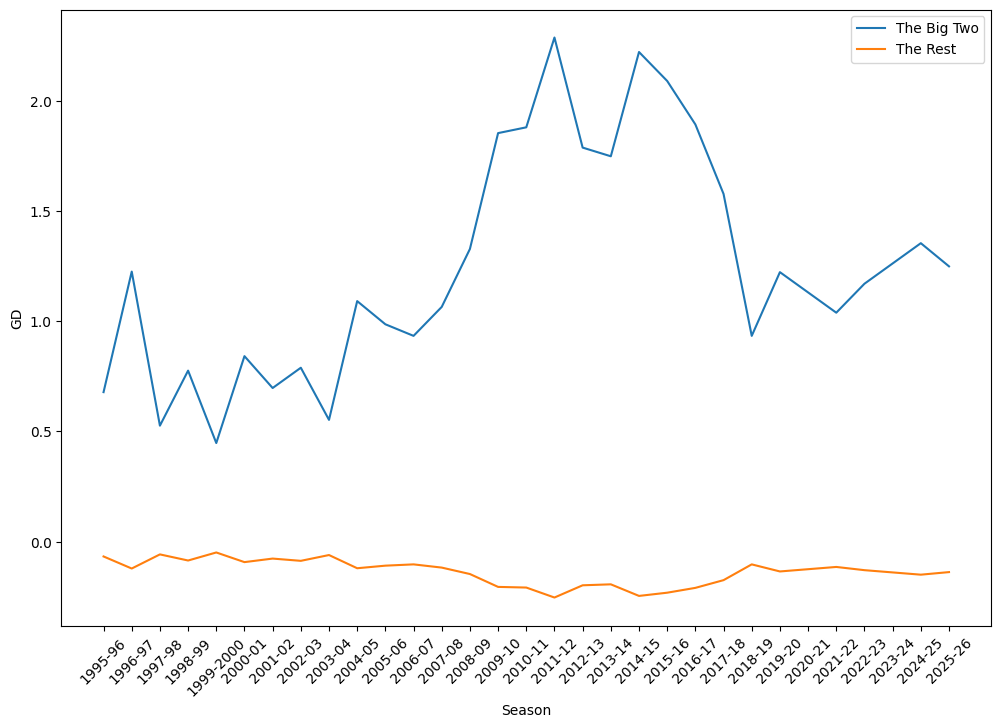

In [14]:
plt.figure(figsize=(12, 8))
sb.lineplot(data = big_two_trend, x = 'Season', y = 'GD', label = 'The Big Two')
sb.lineplot(data = rest_trend, x = 'Season', y = 'GD', label = 'The Rest')

plt.xticks(rotation = 45)
plt.legend()

plt.show()